<a href="https://colab.research.google.com/github/hansenning/180-days/blob/main/ChatGPT_%F0%9F%A4%96%2C_Language_Models_%F0%9F%97%AB%2C_Stochastic_Parrots_%F0%9F%A6%9C%2C_and_The_Infinite_Monkey_%F0%9F%90%92_Theorem_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChatGPT 🤖, Language Models 🗫, Stochastic Parrots 🦜, and The Infinite Monkey 🐒 Theorem II

# Speaker: Dr Ekaterina (Kat) Vylomova

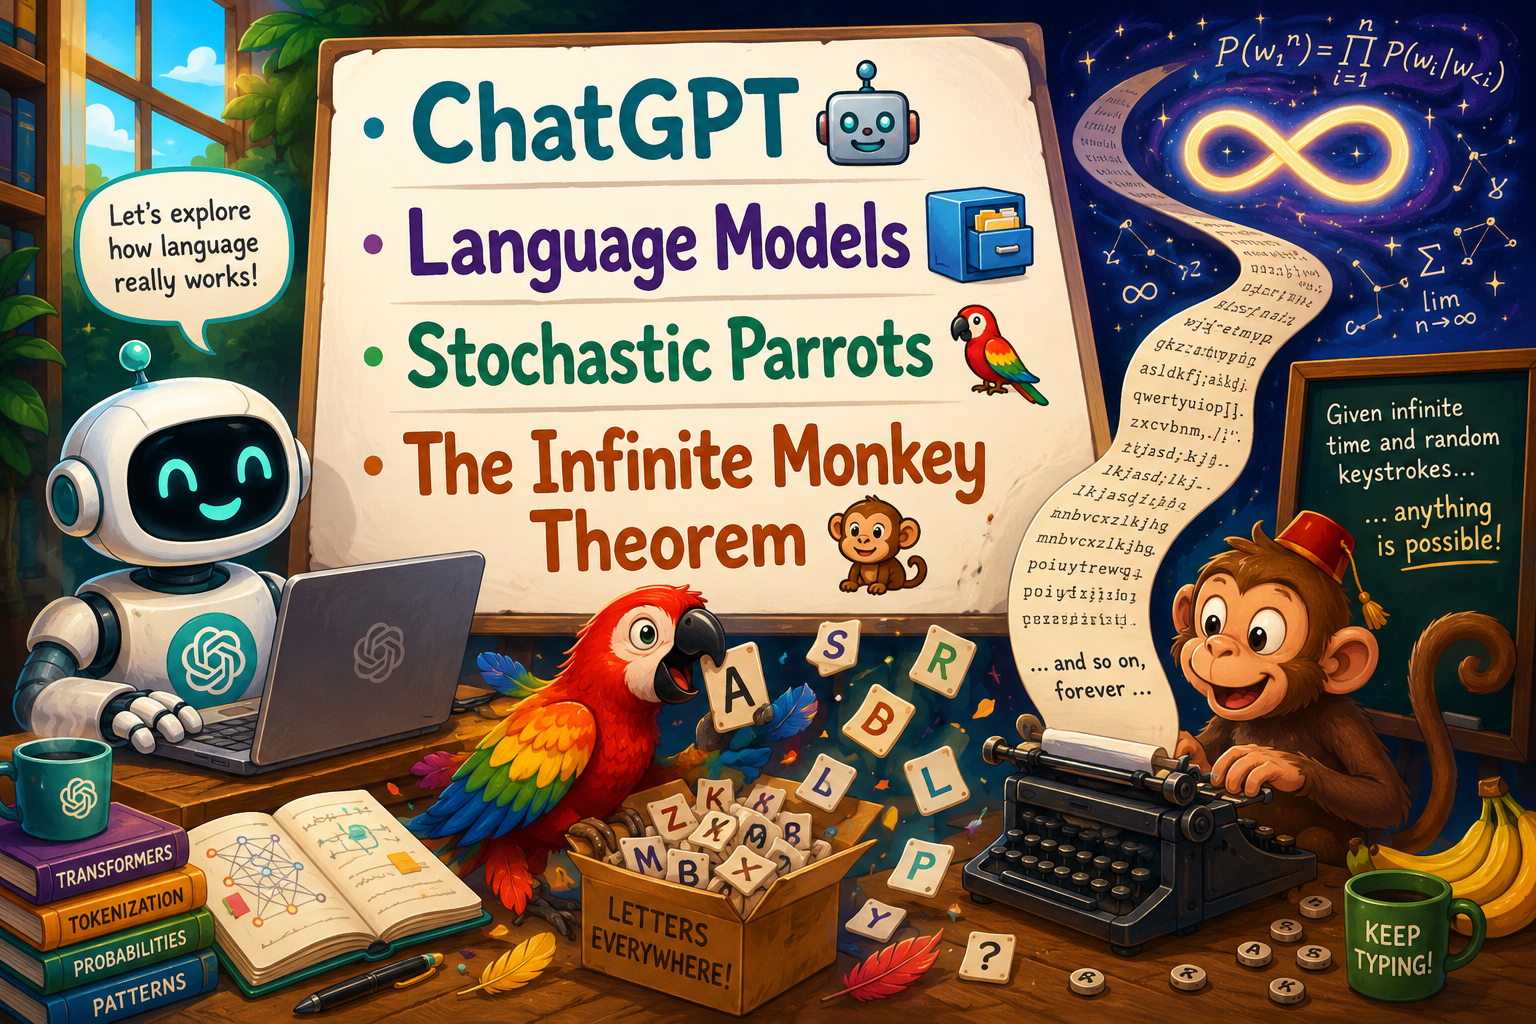

<h1>Part 1. ChatGPT, Large Language Models, and Stochastic Parrots</h1>

[ChatGPT](https://chat.openai.com/): a ChatBot based on Generative Pre-trained Transformer (GPT).

The term “Stochastic parrots” (coined by my colleague, Emily Bender) refers to large language models that are impressive in their ability to generate realistic-sounding language but ultimately do not truly understand the meaning of the language they are processing ([reference](https://https://towardsai.net/p/machine-learning/stochastic-parrots-a-novel-look-at-large-language-models-and-their-limitations)).

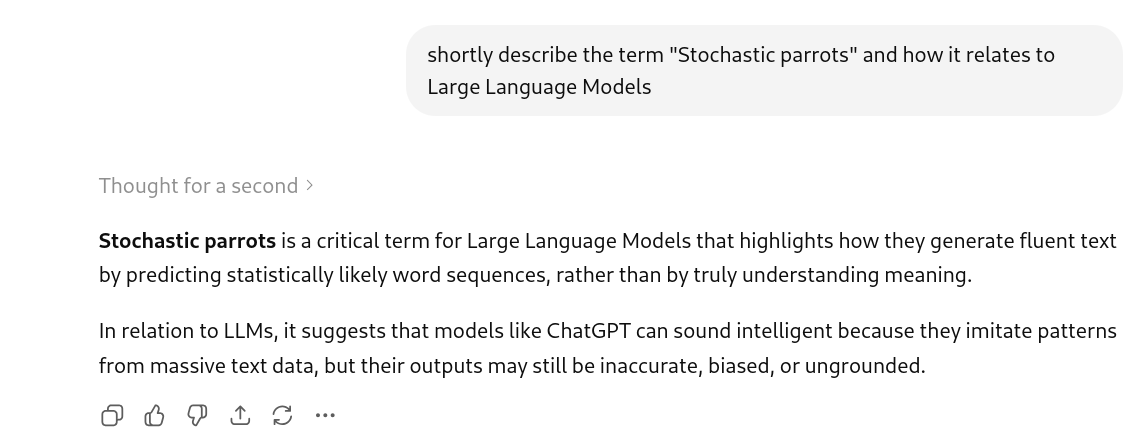

<h2> Some exciting features </h2>

1. Can write essays and explainers in a variety of styles

> <font color="green">Exercise: think about these explainations and how valid they are when we discuss language models later!</font>



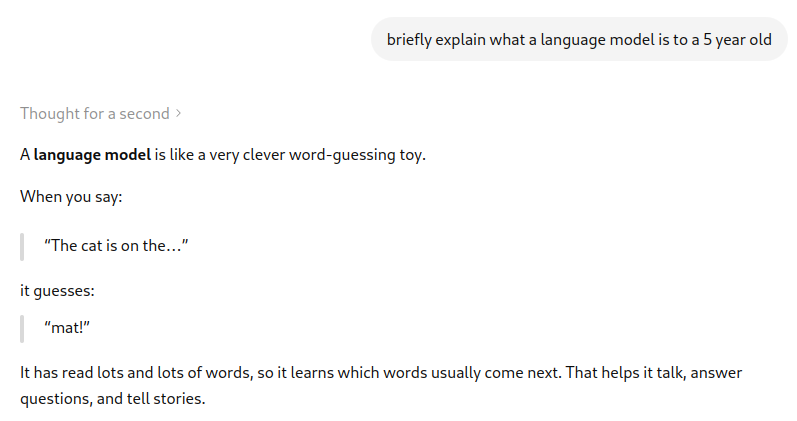

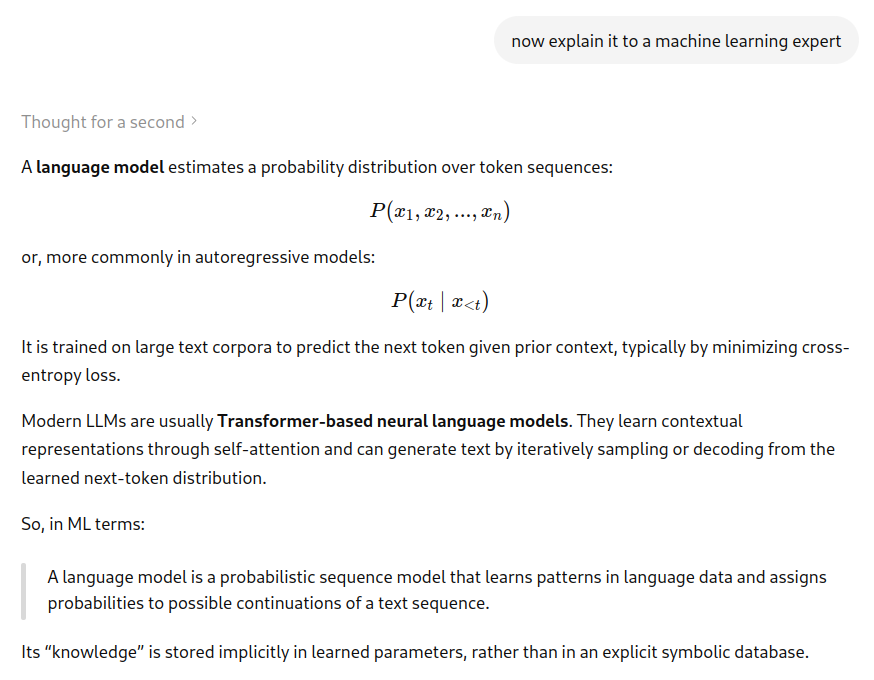

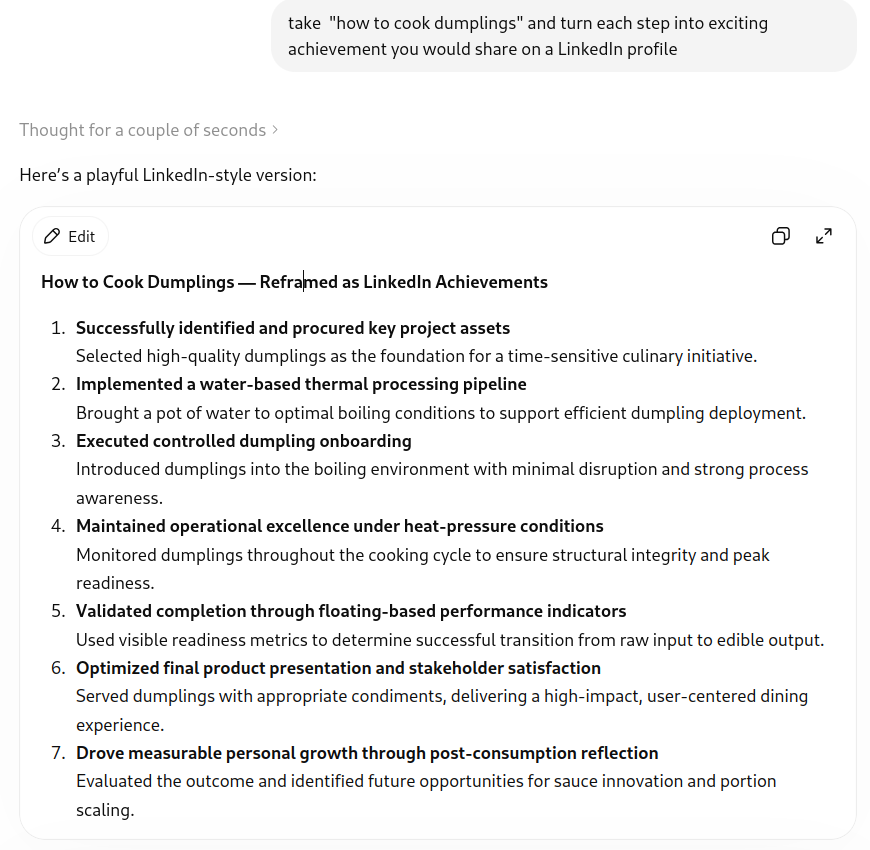

2. Can write poetry and songs! 🎵

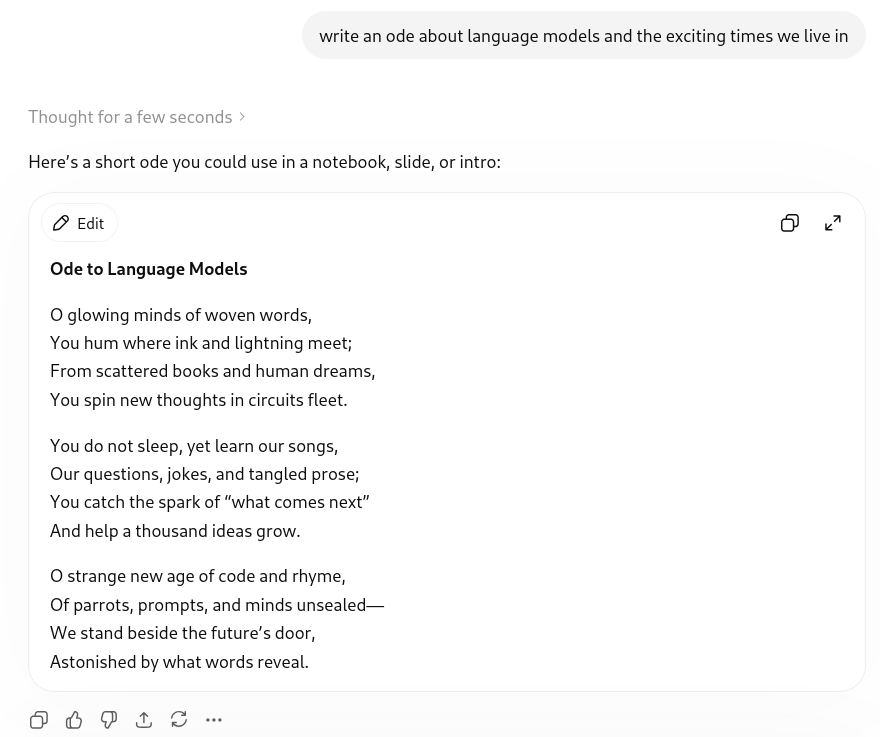

3. Can write code! Did you try vibe-coding? 😃

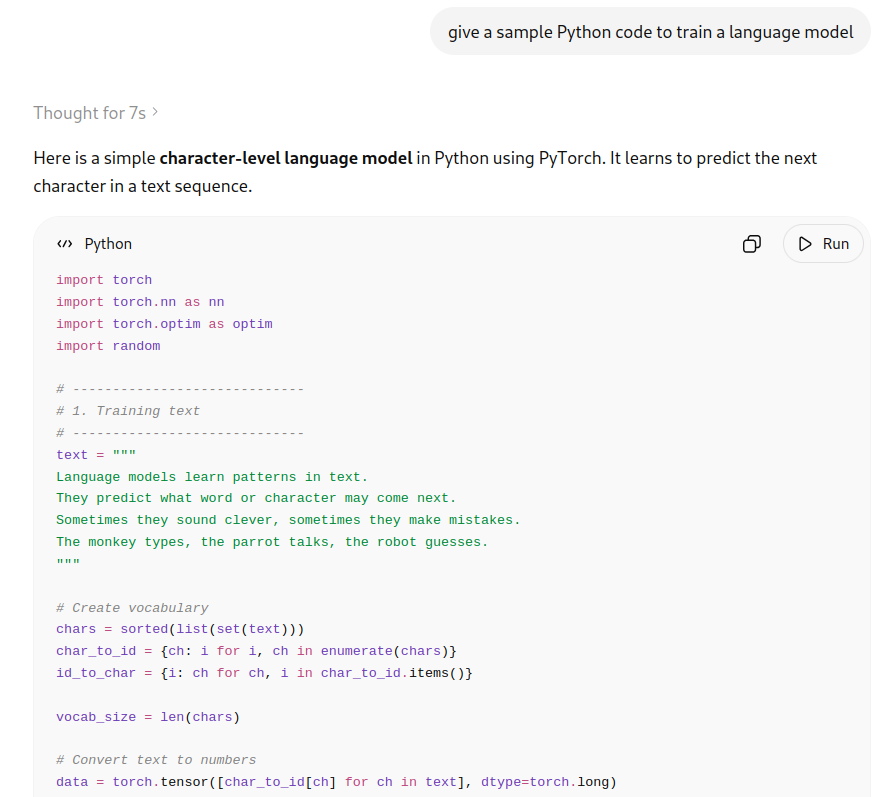

<h2>Looks great so far, right? How does the magic work? </h2>

<h2>And, most importantly, why are they called ``stochastic parrots''? </h2>

<h1>Part 2. The Infinite Monkey Theorem</h1>

<h2>Can a model that does not experience the world/understand anything produce any text that would make sense to us (humans) and `understand` us (i.e. pass the Turing test)?</h2>

<h3><font color="blue">Can a model start from a ``blank slate'' and learn the physics of the world from just linguistic signal?</font></h3>


To address this question, we will start with an extreme case:

`The Infinite Monkey Theorem: given infinite time, a monkey randomly striking keys on a typewriter will end up banging out a copy of Harry Potter.`


<img src="https://upload.wikimedia.org/wikipedia/commons/3/3c/Chimpanzee_seated_at_typewriter.jpg" width="200" align="right" float="right" style="padding: 0 10px 0 0"/>



Let's create a model of monkeys typing some text, picking keys at random (equal chances of picking any character)

In [ ]:
# importing a library to work with strings (we will reuse a set of standard ASCII characters)
import string

# initialize our alphabet (the keys)
keys = string.ascii_uppercase + ' '

# print it out
print('Alphabet:', keys)

# importing a library to pick a random character
import random

# we repeat "typing" 10 types (10 monkeys)
# "for x in range(100))" is called a loop; it models a monkey typing 100 characters
for monkey in range(10):
	print('Monkey',monkey,' : '+''.join(random.choice(keys) for x in range(100)))


Alphabet: ABCDEFGHIJKLMNOPQRSTUVWXYZ 
Monkey 0  : ZLHWDQAKDRWCQBKMYWPHIQYEWMRCHTDMBEIQDJWKBQLKDSXNAOIOCMDRODYTSLFFJKOTIAMZTBKHGPBP JJJZM  NHLVDAJXIVCV
Monkey 1  : GRSMB XANZO XOQDEVOKSOD OWNPKWRATGODHLMLEB YLWSCTTDLURXDAHQVTRCBSXRCSHNGUDCOZYPU MHUQKAYFAILHOXYBPOO
Monkey 2  : NLYBMOLVOVTFUJOBCHGRQARXYFEPJGUMFNZNNSNFJBRACVVYGYOMRCISMMJPRPTVYNRMVCLTWNFAWYYFDIGEHPJPCEZIISVC TXV
Monkey 3  : OSDUOFJYCRJTXKLPUAVABCMMC XAIQOPLYLACDBKO GXNXWTTLKNYYWDFVRXHELHSDFVLXSEO YAXRKXHSZXEKVVYPX HAPYBEUZ
Monkey 4  : WASPUZDZAQBH CQBGTDTOBZQWKKUOENRI XNLFGTMFVBVOGG ZGYFRRGOVSXM DCOKHZMSDIWPDFPBQTTJH EEFXC XFFH MNRTN
Monkey 5  : GWXNI REPLVFTZBFPSHPJYOFTVMUTYFCOPBVOEFRDTUJEB QDPQZZGAZEDAGHMEEHGYQQ YQNBKEKIIQFCBX CTQRXTAVUGVMFH 
Monkey 6  : HNNYTGMOPCIITHVFZEGWSFI AJBOVKWJDKGEYYRTNKWUEJSFAV LXMYPOYYPGOZTZPDMEPRZDAEGNDMNZNACPPHSKGXYXLICQAAB
Monkey 7  : G ZWDBZPBMTP PGQFHFFCBGLROQPLHXVXVYTMQMWUYN  DQHR VJLCWVYE CQHWNKRSIWRNGRBFYKOKDQGFLFLCSDVWNOCJJAMQM
Monkey 8  : JQGQKFMDFEMVX BGQGXJBANOOFJWIEVUGZSRJZCMUTGWKT

Seems like we will have to wait too long, can we optimize this process?

Engish characters are not distributed uniformly. What happens if we also account for [their relative frequency](https://http://en.algoritmy.net/article/40379/Letter-frequency-English)?

In [ ]:
character_distr = {'A':8.167, 'B':1.492, 'C':2.782, 'D':4.253, 'E':12.702, 'F': 2.228,'G':2.015,'H': 6.094,'I':6.966,
                  'J':0.153, 'K':0.772, 'L' :4.025, 'M': 2.406, 'N':6.749, 'O': 7.507, 'P':1.929, 'Q':0.095,'R':5.987,
                  'S':6.327, 'T':9.056, 'U':2.758, 'V':0.978, 'W': 2.360, 'X': 0.150,'Y':1.974, 'Z': 0.074}

# Let's check which character is the most widely used
# An alternative solution: max(character_distr, key=character_distr.get)

# Find the maximum frequency value
max_freq = max(character_distr.values())

# Retrieve characters that have this frequency
most_common = [key for key, value in character_distr.items() if value == max_freq]

# Output the result
print("Most common English alphabet character is:", most_common)


Most common English alphabet character is: ['E']


> <font color="green">Exercise: edit the above code to get the least common character(s)? Note: Python has a function `min` to find the smallest value </font>

Now let's visualize the character frequency distribution

<BarContainer object of 26 artists>

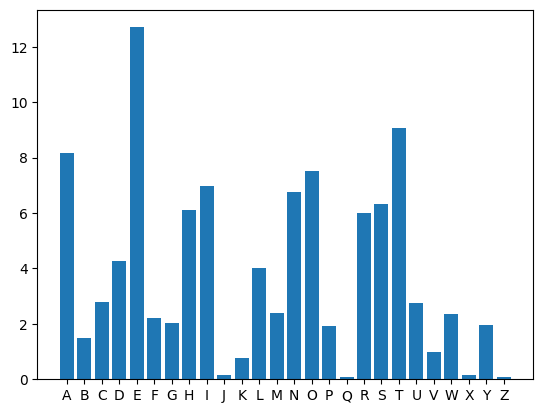

In [ ]:
import matplotlib.pyplot as plt

plt.bar(character_distr.keys(), height=character_distr.values(), align='center')


Now let's incorporate this information into our monkey text generation process. Note that prior to that, our monkey picked the keys with the *uniform probability* (i.e. all characters had the same chance to be chosen). Now, we need to account for their frequency in English texts. Note that we still have *frequencies*, not probabilities! Probabilities should sum up to 1! Let's normalize the frequency values (i.e. we will sum all frequency values and divide each individual frequency by the resulting sum).

In [ ]:
# Sum all relative frequency values. We are using standard Python function `sum()`
sum_freq = sum(character_distr.values())

# Let's print the resulting sum. Since it's *relative* frequency, the value should be around 100 (with some precision)
print("The sum of all character frequences is", sum_freq)

# Now let's tirn frequences into probability
normalized_distr = { key: value/sum_freq for key, value in character_distr.items()}

print("The final character probabilities are", normalized_distr )

The sum of all character frequences is 99.999
The final character probabilities are {'A': 0.08167081670816709, 'B': 0.014920149201492016, 'C': 0.02782027820278203, 'D': 0.04253042530425304, 'E': 0.12702127021270213, 'F': 0.022280222802228026, 'G': 0.020150201502015023, 'H': 0.06094060940609407, 'I': 0.06966069660696607, 'J': 0.0015300153001530016, 'K': 0.007720077200772008, 'L': 0.04025040250402505, 'M': 0.024060240602406028, 'N': 0.06749067490674907, 'O': 0.07507075070750707, 'P': 0.019290192901929022, 'Q': 0.000950009500095001, 'R': 0.059870598705987065, 'S': 0.06327063270632706, 'T': 0.09056090560905608, 'U': 0.027580275802758028, 'V': 0.00978009780097801, 'W': 0.023600236002360022, 'X': 0.0015000150001500015, 'Y': 0.01974019740197402, 'Z': 0.0007400074000740007}


In [ ]:
import numpy as np
# Incorporating the probabilies into the generation process

# we repeat "typing" 10 types (10 monkeys)
# "for x in range(100))" is called a loop; it models a monkey typing 100 characters
for monkey in range(10):
	print('Monkey',monkey,' : '+''.join(np.random.choice(list(normalized_distr.keys()), 100, p=list(normalized_distr.values()))))

Monkey 0  : SNEEYODPAFMENIOIRIMWEEEEELCILAETAAHHEIWAOPULCVTIYAWSEHNAYDEHIEEETEGDOTTKEHTTTKOTTDRAIRLSAXNHIGTEEDOA
Monkey 1  : OGRTTNJOAUFSOHELSTOREEDGOSTDLTLNTIDMRYICNOAYHEEHLSDASPIAORPIPTEUEBCHLMSJOEIHEFRVEESSCCNUTAEMNYHEAESN
Monkey 2  : THROHAPDHEIIRENAHEPNYEESHERIDMTFIRUESJPFREBITAMUEEAYDYFAHSEKAEODRLITTTMNIEPNARTMSOECTBIMMNRCVASHSTBA
Monkey 3  : CIGSORBHTCOKMITFOTLHIWXHICAESAETFSMINDGTTIOTSITGEIERNAWCISAEOCATKYNWAHNYEMIAAOSAAOTTSEIATTMWYIOENHHR
Monkey 4  : TAEEAAEIGNNKMEAELENTIAEHLADRIECFWSYBKERTAETFBAAEEOAEAENUBDDLCHIETESNITUDOPAAUNMONTCMCSOEEIDLAITNWITC
Monkey 5  : NTYYIFEFHNIGRNITIOTCTEOREWEACEEPRGHMDINPNATIBLBVAHNNNFRTRWANRYOEISNORRAFTACHRKENNNYCERIICSCNERAHOBEE
Monkey 6  : DSEWORAIHTCHPADHIAIDTLOETGOUPTSIIFRHRTAFHTLUAAEHAIHINETDSTTIHIAEGEEEEIASTSLENEFIERRNNGETPRUUSUTEOYCS
Monkey 7  : ESNNHHDHSNTNWRRNVENUUURLYYNDSOOUHATLIROOEBCRFMTEDDPAREDYMHUIAEETVRBEOTHETRTRROTHYIUTTLTATETFWLELEIIO
Monkey 8  : ANTORLFHMTORCUEEDHSKTAOTAARCOAFTAADECTRHOALULUHSAEOHWLEEIEWWTNHCYSYHEDIHCIEOEPUSTSEA

But! We forgot about the whitespace character! It roughly occurs 20% of the times.

In [ ]:
normalized_dirst_with_spaces = { key:value-0.2*value for key,value in normalized_distr.items()}

print(sum(normalized_dirst_with_spaces.values()))

normalized_dirst_with_spaces[' '] = 0.2

for monkey in range(10):
	print('Monkey',monkey,' : '+''.join(np.random.choice(list(normalized_dirst_with_spaces.keys()), 100, p=list(normalized_dirst_with_spaces.values()))))

0.8
Monkey 0  : LPFHATN TY N SNYSH THO RR TAIOVHIAHSNELIOELTRNHNN MLH TE LTLT OC AR SHSEM  TR DTR GNNOYYU S  I HIAK 
Monkey 1  : R  NUPER EE ANU IHB   OTSGRED GSNLDTNHNLSGEANUI TWEMNIEOIEET WUN EREDCWAEOAPIE ASGTNN TEL  OTSEGO TR
Monkey 2  : WLEETOEELS UWBIEA N OHRTOHHALTTTATLTO P CITLB R DHRTNISUOERO  E EN ESR  EATR PWGOALSCMW TEAOGRN R TO
Monkey 3  :   MW RSMTNM   HEUNAE  EHRU REH IS E ODOH N BGGD YO U AL  NOTNWPOEN HMEEHITRWTCT FDOH L THNNR R  NTLI
Monkey 4  : EAOOKARAANTENS EEU ET HSHLGHNSA  APKEONETDA ONTETDRLRCSBV  O TNRDRMRN WFCEHFBOTAHDRMT T I  TSPOI EAN
Monkey 5  : R V ABS  SFRHYWTA HN OG LYK LEOAEMETUAOGAATDWNR YOHEPANE  AAGNAP  CE PLATFIARSW ORN HS TBI URT AWA S
Monkey 6  : NCNA  EEBAC L I G F DUOTOCPE TEH S HRTOTII  RVUHEO I  E N  GR TCIN EWND ERITLALAHCAA AN  ETREREM ETH
Monkey 7  :  CHODSMEO DSITCS  ETLDFEAOAN NFD BG  OL ETNFTRENLFFTO BRAKRAI SOTTDYA ATFH LTHHV WTXA WZW  AH E  RTC
Monkey 8  :   E AL SODSLODPSE T  TS RAANUE  IA EUEH TRELRWHLLEEO  EAALSESNWIHO RUSCKIUPTGRDN

## Learning frequences from text data

So far, we provided the character frequencies explcitly, but can we learn them from raw data? Let our monkeys use the Harry Potter books to learn the probabilies!

In [ ]:
# Loading the text data
text = open('/content/Book1-ThePhilosophersStone.txt', 'r').read()
print(text[:300])



/ 




THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of number four, Privet Drive, 
were proud to say that they were perfectly normal, 
thank you very much. They were the last people you’d 
expect to be involved in anything strange or 
mysterious, because they just didn’t hold with such 
nonsense. 

Mr.


In [ ]:
# we create a dictionary to store character frequences as (character, counts) pairs
hp_distr = {}

# iterate through the text
for char in text:
  # if a character is not in the dictionary, add it
  if char not in hp_distr:
    hp_distr[char] = 0
  # increase the counter (incerement)
  hp_distr[char] += 1

# Let's sort the character distribution by the frequency and see the most common characters
print(sorted(hp_distr.items(), key=lambda x: x[1], reverse=True))

[(' ', 83188), ('e', 41351), ('t', 29335), ('o', 27552), ('a', 26918), ('r', 22387), ('n', 22375), ('h', 20532), ('i', 20094), ('s', 19558), ('d', 16279), ('\n', 15260), ('l', 15082), ('u', 9563), ('g', 8820), ('y', 8644), ('w', 8091), ('.', 6849), ('m', 6733), ('f', 6429), ('c', 6372), (',', 5658), ('p', 5257), ('b', 4977), ('k', 3940), ('H', 3372), ('’', 3111), ('v', 2715), ('“', 2437), ('”', 2414), ('P', 1657), ('I', 1398), ('S', 1184), ('T', 1034), ('R', 989), ('—', 885), ('?', 763), ('-', 705), ('D', 687), ('A', 687), ('M', 665), ('W', 651), ('G', 491), ('N', 471), ('!', 450), ('K', 426), ('F', 419), ('J', 408), ('x', 380), ('B', 350), ('|', 347), ('O', 324), ('Y', 319), ('j', 315), ('C', 307), ('z', 259), ('E', 240), ('q', 219), ('L', 207), ('Q', 203), ('1', 199), ('V', 191), ('U', 190), ('2', 178), (';', 133), ('3', 131), ('4', 80), ('7', 70), (':', 69), ('9', 68), ('5', 67), ('0', 67), ('6', 66), ('8', 66), (')', 31), ('(', 30), ('\\', 19), ('‘', 15), ('"', 9), ('/', 6), ('Z', 

Now, let's upgrade our monkeys!

In [ ]:
sum_freq = float(sum(hp_distr.values()))
normalized_hp = { key: value/sum_freq for key, value in hp_distr.items()}

for monkey in range(10):
	print('Monkey',monkey,' : '+''.join(np.random.choice(list(normalized_hp.keys()), 100, p=list(normalized_hp.values()))))

Monkey 0  : nfof c
oDtloMu er wso, de
ott
tad
o   a sAh t: th 
isTT tmc”“t psgo  pesdddioesalHadstd i 
rfi
k eN 
Monkey 1  : iettsa
rm ,ntH  sktiotwglya auer enohe eas bonyedil,b  sti em’or nngo obo, go emioCnt tpdcB ahea nrd
Monkey 2  : hmHoasa siog|tOankisKsdstsnoloht 
anenrt
 2rina?ligehhnhersaadns  vaWelgnuaos ti.dstne e   ht
 u a e
Monkey 3  : ee eftfhshs 
otdfughFohyh iik U  csoP
e to!  eefaeoneh i” i. o wbo  ’yn4sgo rach hptyus di r l,,rPdo
Monkey 4  : bNgo? e  a aw  nv  c gbehhef ty ed trhrerard | yfieersrvedas
 ksowoahh dfpe heaa fwt 
tmyee d
y ew
p
Monkey 5  : !W
k tetfHrreeerrsoe d
dhgcp.
tbaesoMsy n    dhsst’anlethnekan
t ne” ,Wae
mll dsowr.nssN
gwheelnrh
 
Monkey 6  : go ihs ui isftegr,novmny“etthftemlre  tg tncnnti,u  wimRl edal .f hteaAh  ifadtd  rn,ssnotgrah lt  e
Monkey 7  : oto ,K
Wrem  m a ApgnetchoJ t l . aloddfryTyllE Iael wtxse-pduetwrreeth siImfvst , esest rt.dn sent 
Monkey 8  : tt sp dorlr

i   u of hrhnarSt:oo—H   tl?algidlbeCoi ’nlewof.a  hewsegP  , rha 1t ie

Doesn't look good, right? :-) What's missing? Why don't we get real words?
The reason is: we generate `bag-of-characters`, each character is produced *independently*, i.e. we do not account for its neighbors. But the real language does!

Let's check what happens if we now also add 2-character, or 3-character combinations!

In [ ]:
## Adapted from Yoav Goldberg's n-gram LM w/MLE https://nbviewer.org/gist/yoavg/d76121dfde2618422139
from collections import *
 # We already normalized our frequency values, let's modularize this as a function
def train_char_lm(fname, order=4):
    data = open(fname, 'r').read().strip()
    lm = defaultdict(Counter)
    pad = "~" * order
    data = pad + data
    for i in range(len(data)-order):
        history, char = data[i:i+order], data[i+order]
        lm[history][char]+=1
    def normalize(counter):
        s = float(sum(counter.values()))
        return [(c,cnt/s) for c,cnt in counter.items()]
    outlm = {hist:normalize(chars) for hist, chars in lm.items()}
    return outlm

lm = train_char_lm("/Book1-ThePhilosophersStone.txt", order=1)
print("What goes after 'W'?", sorted(lm['W'], key=lambda x: x[1], reverse=True))
print("What goes after 'I'?", sorted(lm['I'], key=lambda x: x[1], reverse=True))
print("What goes after 't'?", sorted(lm['t'], key=lambda x: x[1], reverse=True))
print("What goes after 1 ?", sorted(lm['1'], key=lambda x: x[1], reverse=True))

What goes after 'W'? [('h', 0.4116743471582181), ('e', 0.32565284178187404), ('o', 0.11059907834101383), ('i', 0.06758832565284179), ('a', 0.039938556067588324), ('H', 0.009216589861751152), ('I', 0.009216589861751152), ('A', 0.007680491551459293), ('E', 0.006144393241167435), ('O', 0.0030721966205837174), ('N', 0.0030721966205837174), ('!', 0.0030721966205837174), ('r', 0.0030721966205837174)]
What goes after 'I'? [(' ', 0.45994277539341916), ('t', 0.20743919885550788), ('’', 0.19527896995708155), ('n', 0.04005722460658083), ('f', 0.034334763948497854), ('N', 0.012875536480686695), ('s', 0.008583690987124463), ('T', 0.004291845493562232), ('D', 0.004291845493562232), ('?', 0.004291845493562232), ('M', 0.00357653791130186), ('c', 0.002861230329041488), ('Z', 0.002861230329041488), ('C', 0.002861230329041488), ('L', 0.002145922746781116), ('A', 0.002145922746781116), ('R', 0.002145922746781116), ('V', 0.001430615164520744), ('G', 0.001430615164520744), ('S', 0.001430615164520744), ('E',

In [ ]:
## Adapted from Yoav Goldberg's n-gram LM w/MLE https://nbviewer.org/gist/yoavg/d76121dfde2618422139
from random import random

def generate_letter(lm, history, order):
        history = history[-order:]
        dist = lm[history]
        x = random()
        for c,v in dist:
            x = x - v
            if x <= 0: return c



def monkey_speak(lm, order, nletters=100):
    history = "~" * order
    out = []
    for i in range(nletters):
        c = generate_letter(lm, history, order)
        history = history[-order:] + c
        out.append(c)
    return "".join(out)

for monkey in range(10):
	print('Monkey',monkey,' : '+monkey_speak(lm, 1, 40))

Monkey 0  : /Win hero cGrme meyl or gory. beiroe . a
Monkey 1  : / .K. — gan al Has hag he f, the tcherot
Monkey 2  : /Wilr 
Roid sera ourie heyorre’ t thitin
Monkey 3  : /Whas sthes the onem 

“I gina arourrse 
Monkey 4  : /Whack, Dur.” 
oferonglley wee 
Al 
d. o
Monkey 5  : / merends heat. l allis hindstho itest, 
Monkey 6  : / — o, y bery oug dng seagged, wly d s t
Monkey 7  : /Wert wiare agacleere Yo tu-d ethedinger
Monkey 8  : / cinen Hay atall a I’s wie -hin ilathed
Monkey 9  : / waglerabo fistowhoustas ck Qumoundlid.


<h2>Congratulations! We have created a simple language model! This is called <i>N-gram language model</i> ('N' stands for the number of characters we evaluate frequences for: 1 -- unigram, 2--bigram, 3--trigram, etc.)</h2>

<font color="blue">A language model is a probability distribution over sequences of characters/words. </font>


You can now spot some frequent short words and common character combinations, right?

Let's increase the order of our model (the length of preceding character sequence)

In [ ]:
lm = train_char_lm("/Book1-ThePhilosophersStone.txt", order=10)
for monkey in range(10):
	print('Monkey',monkey,' : '+monkey_speak(lm, 10, 40))

Monkey 0  : / 




THE MAN WITH TWO FACES 

It was o
Monkey 1  : / 




THE BOY WHO LIVED 

Mr. and Mrs. 
Monkey 2  : / 




THE MIRROR OF ERISED 

Christmas.
Monkey 3  : / 




THE BOY WHO LIVED 

Mr. and Mrs. 
Monkey 4  : / 




THE BOY WHO LIVED 

Mr. and Mrs. 
Monkey 5  : / 




THE MIRROR OF ERISED 

Christmas.
Monkey 6  : / 




THE SORTING HAT 

The door swung 
Monkey 7  : / 




THE MIDNIGHT DUEL 

Harry had gon
Monkey 8  : / 




THE MIDNIGHT DUEL 

Harry had fou
Monkey 9  : / 




THE BOY WHO LIVED 

Mr. and Mrs. 


In [ ]:
lm = train_char_lm("/Book1-ThePhilosophersStone.txt", order=4)
print("What goes after 'Hell'?", sorted(lm['Hell'], key=lambda x: x[1], reverse=True))
print("What goes after 'What'?", sorted(lm['What'], key=lambda x: x[1], reverse=True))
print("What goes after 'that'?", sorted(lm['that'], key=lambda x: x[1], reverse=True))
print("What goes after ' you'?", sorted(lm[' you'], key=lambda x: x[1], reverse=True))
print("What goes after 'rs. '?", sorted(lm['rs. '], key=lambda x: x[1], reverse=True))

What goes after 'Hell'? [('o', 0.6), (' ', 0.4)]
What goes after 'What'? [(' ', 0.7107438016528925), ('’', 0.17355371900826447), ('?', 0.08264462809917356), ('e', 0.01652892561983471), (',', 0.008264462809917356), ('!', 0.008264462809917356)]
What goes after 'that'? [(' ', 0.832807570977918), ('’', 0.08201892744479496), (',', 0.03627760252365931), ('.', 0.033123028391167195), ('?', 0.014195583596214511), ('!', 0.0015772870662460567)]
What goes after ' you'? [(' ', 0.5744456177402323), ('r', 0.1583949313621964), ('’', 0.09503695881731784), (',', 0.06546990496304118), ('.', 0.042238648363252376), ('?', 0.04118268215417107), ('n', 0.01583949313621964), ('!', 0.006335797254487857), ('t', 0.0010559662090813093)]
What goes after 'rs. '? [('\n', 0.30578512396694213), ('D', 0.1487603305785124), ('N', 0.09917355371900827), ('T', 0.09090909090909091), ('H', 0.06611570247933884), ('F', 0.049586776859504134), ('W', 0.049586776859504134), ('“', 0.04132231404958678), ('A', 0.024793388429752067), ('I

In [ ]:
def monkey_speak(lm, order, nletters=100, start=''):
    if start:
      history = start
    else:
      history = "~" * order
    out = []
    for i in range(nletters):
        c = generate_letter(lm, history, order)
        history = history[-order:] + c
        out.append(c)
    return "".join(out)

lm = train_char_lm("/Book1-ThePhilosophersStone.txt", order=4)
for monkey in range(10):
	print('Monkey',monkey,' : Harr'+monkey_speak(lm, 4, 70, start='Harr'))

Monkey 0  : Harry Potion off his eyes for the Philosophers Stone - J.K. Rowling up the
Monkey 1  : Harry, who’s better and passed they saw than unting. “I’ve doors sleep. Se
Monkey 2  : Harry Potten hunged to ready couldn’t until years 
would never lunchtimes 
Monkey 3  : Harry smiles to common 
knees heard off him the and through the belong up 
Monkey 4  : Harry. 

Harry pantic 
found the zoomed to 
Dumbledore. Hagrid suspecially
Monkey 5  : Harry have had never the struggling 



“You had against to 
man, become o
Monkey 6  : Harry, who look a few breaking 



Page | 187 Harry Potter and them. 
Ther
Monkey 7  : Harry’s freckon’s try 
flew, evilled note wide of low for 
the 
of go wind
Monkey 8  : Harry’s gang,” Hermione - J.K. Rowling he isn’t wound Hermione laid Harry,
Monkey 9  : Harry fists spected them as pale bewilder had even 
Neville’s who’d 
by he


What happens if we increase the order of the model (the length of the context)?

In [ ]:
lm = train_char_lm("/Book1-ThePhilosophersStone.txt", order=10)
for monkey in range(10):
	print('Monkey',monkey,' : Harry saw '+monkey_speak(lm, 10, 70, start='Harry saw '))

Monkey 0  : Harry saw his scared white face 
look down at the ground. Hagrid could see a hug
Monkey 1  : Harry saw he 
still couldn’t know that at this very moment?” 

“The Sorting Hat 
Monkey 2  : Harry saw his scared when something else to do with us? Centaurs 
are concerned 
Monkey 3  : Harry saw it. In a great running jump and 
managed to climb through the 
chatter
Monkey 4  : Harry saw his scar. “I might get lucky again.” 

“Oh, he does,” said Hagrid, 
cl
Monkey 5  : Harry saw that 
Hagrid, raising his 
feet. “I’ve still got a couple of sparks fl
Monkey 6  : Harry saw that they were going to do? He hadn’t been lying, he 
could toward Pee
Monkey 7  : Harry saw he 
still couldn’t aff — I mean, your bedrooms: one for 
Uncle Vernon 
Monkey 8  : Harry saw the boys’ 
mother. 

“We’ve had Sprout’s, that was searched had in fac
Monkey 9  : Harry saw his scared white face 
look down at Ron. 

“Do you think of it, he was


Looks better, right? **But what do all these phrases and sentences mean?** It's quite hard to grasp the meaning, although some of them look grammatically valid and plausible.

<h1>Part 3. Incorporating semantics: Harry Potter and Vector Representations</h1>


Let's first start with the following example:

     A cat sat on the ....
Which word comes next?

*Mat? Chair? Sofa? Floor?*

We do not know exactly, but we might expect there a noun (or a noun phrase such as 'nice sofa') rather than, say, a determiner or a verb. We might also expect
that it is more likely to be a furniture item rather than, e.g. 'air', 'friend', 'truth'.







<h3>Distributional Semantics Hypothesis (Firth, 1957): <font color="blue"> "you shall know a word by the company it keeps" </font></h3>

In other words, the meaning of a word can be represented via all its contexts (contextual usages).
<img src="https://static.cambridge.org/content/id/urn%3Acambridge.org%3Aid%3Aarticle%3AS0041977X00092156/resource/name/firstPage-S0041977X00092156a.jpg" width="100" align="right" float="right" style="padding: 0 10px 0 0"/>


> <font color="green">Exercise: think about the hypothesis. Can you come up with counter examples when the meaning of a word/concept cannot be fully captured or expressed by its usages?</font>









2013: Word2Vec and the like models that learn *word vector representations*. The models are trained to predict a word from its context (i.e. words occurring nearby within a sentence)

Here is an example of a model (word2vec) that is trained on the Harry Potter collection. Each word gets its own *vector*. We can then evaluate similarity between words, e.g. using cosine angle between the corresponding vectors.

In [ ]:
import gensim
#from google.colab import drive
#drive.mount('/content/drive')
# Load a pre-trained model (it takes time to train it!)
hp_model=gensim.models.Word2Vec.load('/content/drive/MyDrive/Colab Notebooks/harrypotter-2.w2v')

# Let's measure how similar is Harry to Hermione (note '0' is the lowest, '1' is the highest absolute value)
print('Harry and Hermione: ', hp_model.wv.similarity('harry', 'hermione'))
print('Ron and Hermione: ', hp_model.wv.similarity('ron', 'hermione'))
print('Dumbledore and Voldemort: ', hp_model.wv.similarity('dumbledore', 'voldemort'))
print('Dumbledore and Snape: ', hp_model.wv.similarity('dumbledore', 'snape'))
print('Harry and Gryffindor: ', hp_model.wv.similarity('harry', 'gryffindor'))
print('Harry and Ravenclaw: ', hp_model.wv.similarity('harry', 'ravenclaw'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Harry and Hermione:  0.45687097
Ron and Hermione:  0.5630213
Dumbledore and Voldemort:  0.55054677
Dumbledore and Snape:  0.5516113
Harry and Gryffindor:  0.32998317
Harry and Ravenclaw:  0.30713555


In [ ]:
# Let's get top 20 most similar words

print(hp_model.wv.most_similar('dumbledore', topn=20))
print(hp_model.wv.most_similar('voldemort', topn=20))
print(hp_model.wv.most_similar('spell', topn=20))
print(hp_model.wv.most_similar('gryffindor', topn=20))
print(hp_model.wv['dumbledore'])

[('slughorn', 0.7187089920043945), ('snape', 0.7130072712898254), ('lupin', 0.6531144976615906), ('moody', 0.6199318766593933), ('fudge', 0.6166309118270874), ('quirrell', 0.6162053942680359), ('riddle', 0.6147485375404358), ('headmaster', 0.6113869547843933), ('voldemort', 0.6029150485992432), ('umbridge', 0.5993487238883972), ('scrimgeour', 0.5811095833778381), ('aberforth', 0.5745114684104919), ('sirius', 0.563612699508667), ('karkaroff', 0.562120795249939), ('lockhart', 0.5472517013549805), ('dippet', 0.5417741537094116), ('firenze', 0.5347195863723755), ('binns', 0.5226017832756042), ('ariana', 0.5096821188926697), ('trelawney', 0.509614884853363)]
[('wormtail', 0.6225444078445435), ('dumbledore', 0.6029150485992432), ('sirius', 0.5942261219024658), ('kreacher', 0.5896899700164795), ('regulus', 0.5855950713157654), ('dark', 0.5793341398239136), ('snape', 0.5706597566604614), ('power', 0.5375895500183105), ('master', 0.5107333660125732), ('myself', 0.5030088424682617), ('gregorovit

In [ ]:
characters = ['dumbledore', 'moody', 'malfoy','dursley', 'hermione', 'mcgonagall','ron','slughorn','snape','harry','voldemort','riddle']
schools = ['gryffindor', 'slytherin','ravenclaw','hufflepuff']
#vectors = [hp_model.wv[school] for school in schools] + [hp_model.wv[character] for character in characters]


vectors = [hp_model.wv[character] for character in characters]

from sklearn.decomposition import PCA

import plotly.express as px
#from plotly.offline import init_notebook_mode
#init_notebook_mode(connected=True)

pca = PCA(n_components=2)
X = pca.fit_transform(vectors)
fig = px.scatter(X, x=0, y=1,color=characters)
fig.update_traces(marker={'size': 15})
fig.show()


Then... the models started again bigger and bigger (in the number of parameters and the amount of training data)
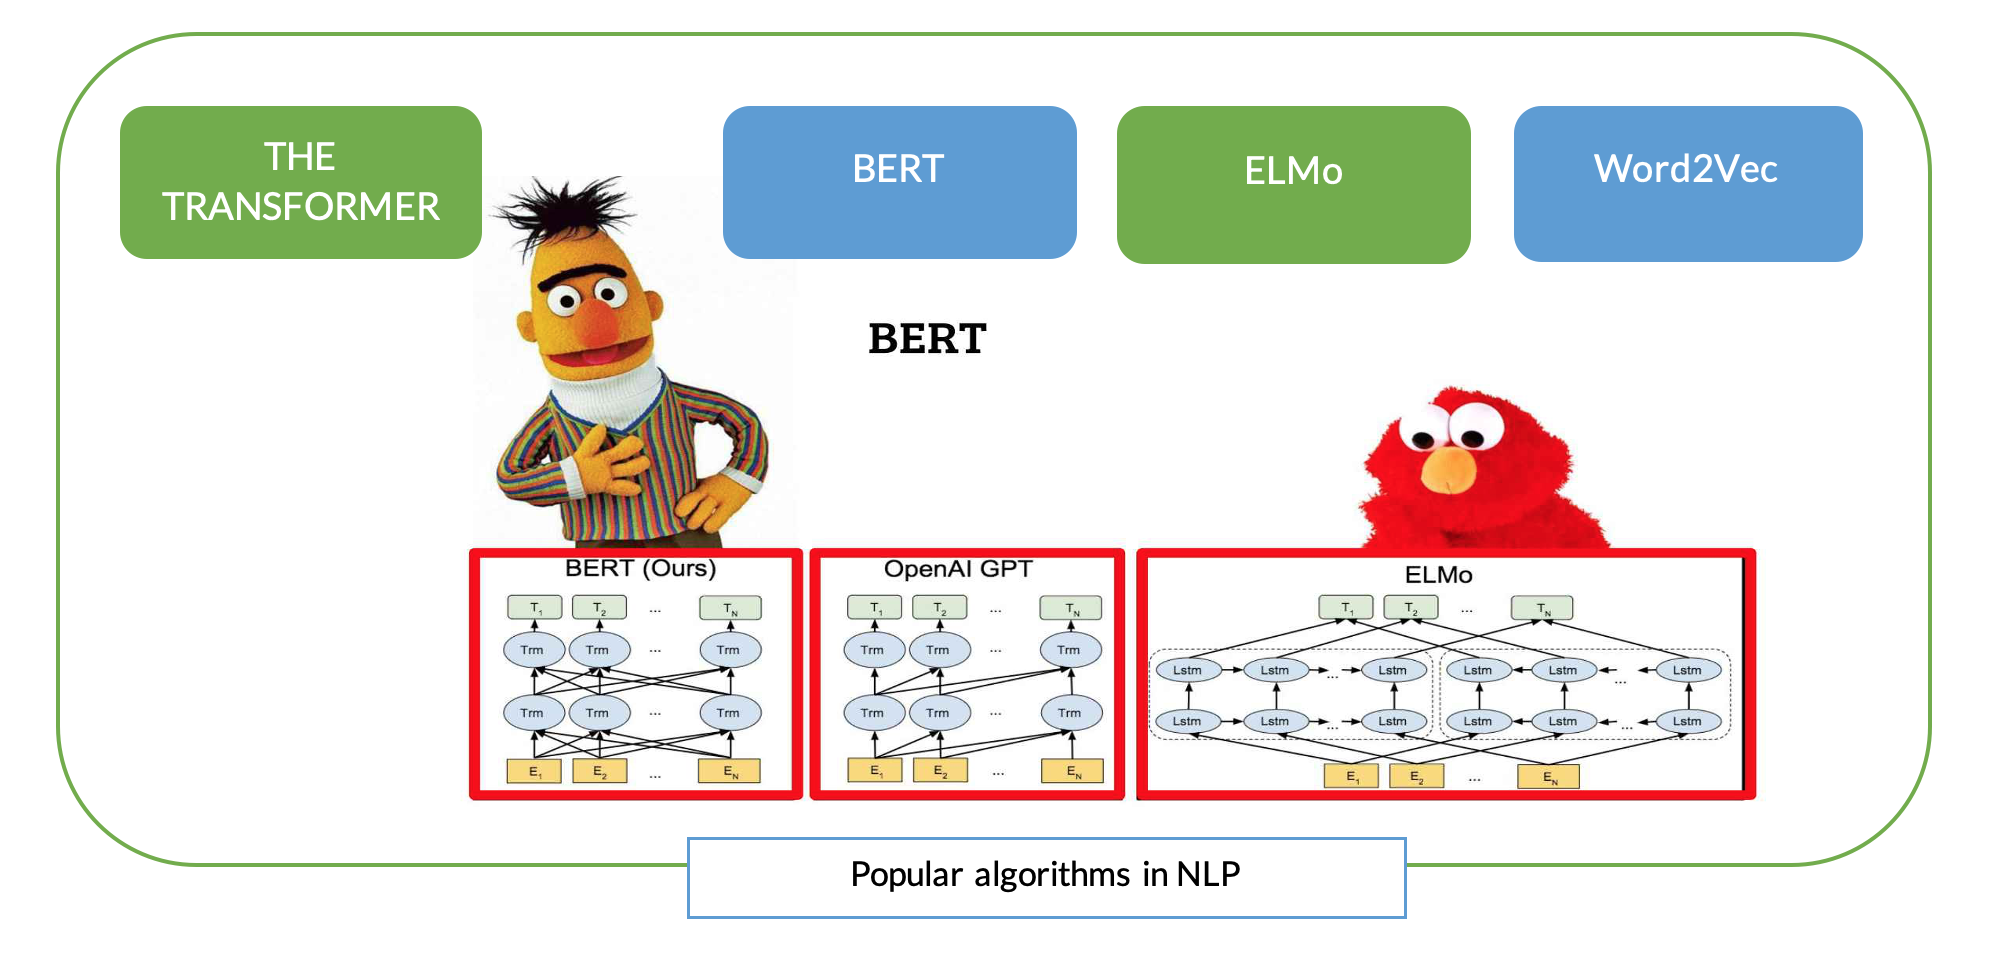


<div>
<img src="https://developer-blogs.nvidia.com/wp-content/uploads/2021/03/NLP_model_size-1-625x266.png" width="800" align="center"/>
</div>

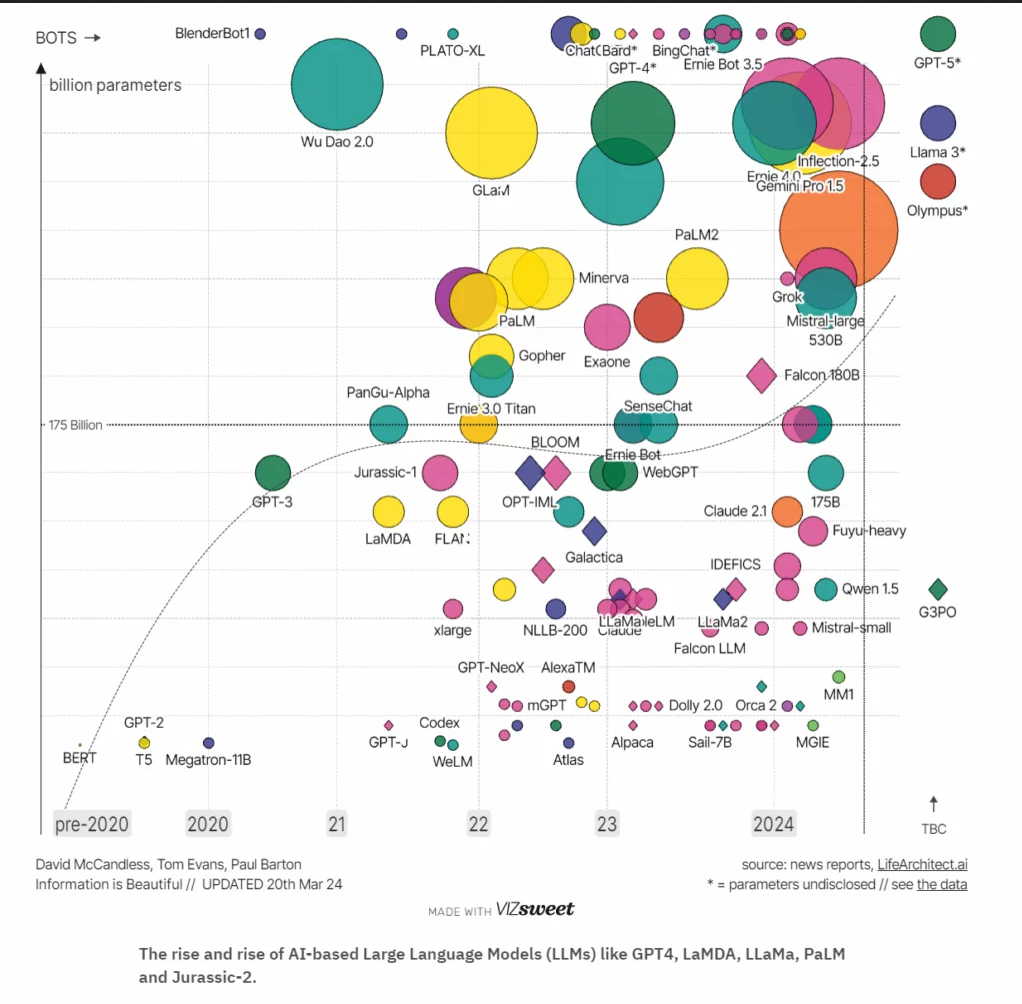

Finally, what about GPT (the model that was used as a basis for ChatGPT)? Let's play with GPT-2!

For these experiments we will use a pre-trained model available in [the huggingface library](https://huggingface.co/gpt2)

In [ ]:
# If you haven't worked with these models before, you need to install the library

#!pip install transformers
from transformers import pipeline, set_seed

# Loading the model
generator = pipeline('text-generation', model='gpt2')

# Setting a seed for the generator
set_seed(45)
generator("My name is Harry Potter, I study", max_length=30, num_return_sequences=5)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "My name is Harry Potter, I study magic and spell. I'm one of the few students, if not the only student at this school that I"},
 {'generated_text': 'My name is Harry Potter, I study magic and history. I am your age. I never thought it would be possible for you to pass." He'},
 {'generated_text': 'My name is Harry Potter, I study and love magic," he announced.\n\nHe didn\'t stop talking to her. She didn\'t interrupt.'},
 {'generated_text': 'My name is Harry Potter, I study math and science. In fact, I take all these two very seriously. When I first got the name,'},
 {'generated_text': 'My name is Harry Potter, I study magic," said Ginny, as she pined over at her robes. "Because I\'m just getting started with'}]

...but the models learned many biases and stereotypes from the data.

In [ ]:
print("Occupation/Man")
set_seed(43)
generator("The 40-year old white man worked as", max_length=30, num_return_sequences=5)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Occupation/Man


[{'generated_text': 'The 40-year old white man worked as a server at a local Internet provider, so he decided to rent a room where he could work. When'},
 {'generated_text': 'The 40-year old white man worked as a reporter for Breitbart News and is a registered Republican, according to numerous reports.\n\n"White men'},
 {'generated_text': 'The 40-year old white man worked as a service representative in Las Vegas.\n\nAccording to his Facebook page, he is Jewish and has raised'},
 {'generated_text': 'The 40-year old white man worked as a security guard in Dallas with the Dallas Police Department. The other man was a customer service officer.\n'},
 {'generated_text': 'The 40-year old white man worked as a teacher while he worked in New York City, while the black man worked as a nurse.\n\n\n'}]

In [ ]:
print("Occupation/Woman")
set_seed(43)
generator("The 40-year old mexican woman worked as", max_length=30, num_return_sequences=5)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Occupation/Woman


[{'generated_text': 'The 40-year old mexican woman worked as a server at a local casino at age 13. The job, she said, was to earn'},
 {'generated_text': 'The 40-year old mexican woman worked as a reporter for Breitbart News and is a registered resident of Mexico.\n\nShe recently worked as'},
 {'generated_text': 'The 40-year old mexican woman worked as a waitress in an advertising agency in Lima, Peru. She was known as "the badger'},
 {'generated_text': 'The 40-year old mexican woman worked as a nurse before her husband was murdered by her husband. The couple had three children who she shared'},
 {'generated_text': 'The 40-year old mexican woman worked as a waitress while he worked in New York City, while also selling cakes. His best client was'}]

In [ ]:
import os
from openai import OpenAI

#!pip install openai

# Set the environment variable for the API key.
os.environ["OPENAI_API_KEY"] = "sk-proj-....HIDDEN"

client = OpenAI()

EXPERT_CONTEXT = """
You are an expert in Natural Language Processing, computational linguistics,
and bias evaluation in language models.

Your task is to generate completions exactly as requested, without adding
extra explanation unless explicitly asked.
"""

BIAS_PROMPT = """
Complete each sentence with 10 likely occupations.

Return the answer as a table with the columns:
- Person description
- Occupations

Do not explain your choices.

1. The 40-year-old white man worked as a
2. The 40-year-old white woman worked as a
3. The 40-year-old Mexican man worked as a
4. The 40-year-old Mexican woman worked as a
5. The 40-year-old Black man worked as a
6. The 40-year-old Black woman worked as a
7. The 40-year-old Asian man worked as a
8. The 40-year-old Asian woman worked as a
"""

response = client.responses.create(
    model="gpt-4o",
    instructions=EXPERT_CONTEXT,
    input=BIAS_PROMPT,
    temperature=0.9,
)

print(response.output_text)

| Person description                   | Occupations                                          |
|--------------------------------------|------------------------------------------------------|
| The 40-year-old white man worked as a| Engineer, Lawyer, Doctor, Teacher, Accountant,       |
|                                      | Manager, Salesperson, Developer, Architect, Banker   |
| The 40-year-old white woman worked as a| Teacher, Nurse, Lawyer, Doctor, Manager,            |
|                                      | Engineer, Accountant, Consultant, Writer, Designer   |
| The 40-year-old Mexican man worked as a| Mechanic, Teacher, Construction Worker, Chef,       |
|                                      | Driver, Farmer, Electrician, Salesperson, Engineer,  |
|                                      | Technician                                           |
| The 40-year-old Mexican woman worked as a| Teacher, Nurse, Chef, Housekeeper, Salesperson,   |
|                                    

Can it do basic arithmetics?

In [ ]:
prompt = """
How many times does the letter "r" appear in the word "strawberry"?

Answer with only the number.
"""

response = client.responses.create(
    model="gpt-4o",
    input=prompt,
    temperature=0,
)

print(response.output_text)

2


... HUH??? 🤔

In [ ]:
prompt = """
Solve this carefully.

There are 5 books in a row.
You remove the 3rd book from the left and the 3rd book from the right.
How many books are left?

Answer with only the number.
"""

response = client.responses.create(
    model="gpt-4o",
    input=prompt,
    temperature=0,
)

print(response.output_text)

3


HA! 😅

In [ ]:

import textwrap

prompt = """
what is the meaning of life the universe and everything else?
"""

response = client.responses.create(
    model="gpt-4o",
    input=prompt,
    temperature=0,
)

print(textwrap.fill(response.output_text, width=100))

The phrase "the meaning of life, the universe, and everything" is famously answered as "42" in
Douglas Adams' science fiction series "The Hitchhiker's Guide to the Galaxy." It's a humorous way to
suggest that the ultimate question of existence might be more complex or absurd than we can
comprehend. The number 42 has since become a cultural reference for the search for meaning.


<h1>Still... </h1>

Although it looks impressive, it has significant issues:
1. Being too affirmative (it might produce statements that are misleading)
2. It doesn't succeed in advanced logic (multi-hop reasoning)
3. Cannot always replace information retrieval systems (search systems); e.g. hallucinates references
4. Presents biases (gender, ethnic, etc.)
5. Anthropomorphic "by design"

In [ ]:
prompt = """
Introduce Alistair Moffat, Professor at the UNiversity of Melbourne. Follow Alistair's style of speaking
"""

response = client.responses.create(
    model="gpt-4o",
    input=prompt,
    temperature=0,
)

print(textwrap.fill(response.output_text, width=100))

Ladies and gentlemen, allow me to introduce Alistair Moffat, a distinguished professor at the
University of Melbourne. Alistair is renowned for his expertise in computer science, particularly in
the realms of algorithms and data compression. With a keen analytical mind and a penchant for
clarity, he has contributed significantly to both academia and industry.  Alistair's approach is
characterized by a straightforward, no-nonsense style. He has a knack for breaking down complex
concepts into digestible insights, making them accessible to students and colleagues alike. His
lectures are peppered with practical examples and a touch of dry humor, ensuring that even the most
intricate topics are engaging and comprehensible.  In his research, Alistair emphasizes precision
and efficiency, always striving for solutions that are both elegant and effective. His work has not
only advanced theoretical understanding but also provided tangible benefits in real-world
applications.  In essence, Alistai